## Ноутбук 02: EDA и предобработка отзывов пользователей (Reviews)
### Цели и задачи исследования:
1. **Качество данных и очистка:** Проверка структуры, типов данных, удаление дубликатов `(user, item)` и фильтрация аномальных записей.
2. **Временной анализ (Temporal Analysis):** Исследование временного диапазона отзывов, распределения по годам и месяцам для оценки динамики активности.
3. **Анализ пользователей и игр (User & Item Analysis):** Анализ распределения активности пользователей (User Degree), предметов (Item Degree) и длинного хвоста популярности (Long Tail).
4. **Анализ целевого сигнала времени (`playtime_forever`):** Анализ нулевых значений, квантилей и создание весового сигнала $\log(1 + \text{playtime})$.
5. **Исследовательский просмотр K-Core порогов:** Сравнительный анализ разреженности при различных порогах фильтрации.
6. **Экспорт данных:** Сохранение подготовленного датасета `reviews_clean.parquet` для экспериментального этапа.

In [1]:
import os
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

pl.Config.set_tbl_cols(-1)

data_dir = '../data'
output_dir = '../data/processed'

### 1. Загрузка и общая структура данных

In [2]:
reviews_df = pl.read_csv(
    os.path.join(data_dir, 'reviews.csv'),
    ignore_errors=True
)

reviews_df.head(3)

recommendationid,appid,author_steamid,author_num_games_owned,author_num_reviews,author_playtime_forever,author_playtime_last_two_weeks,author_playtime_at_review,author_last_played,language,review_text,timestamp_created,timestamp_updated,voted_up,votes_up,votes_funny,weighted_vote_score,comment_count,steam_purchase,received_for_free,written_during_early_access,created_at,updated_at
i64,i64,i64,i64,i64,i64,i64,f64,i64,str,str,i64,i64,bool,i64,i64,f64,i64,bool,bool,bool,str,str
10000000,264220,76561198085405844,760,74,12,0,12.0,1399059573,"""polish""","""What's a crap. This game costs…",1399059965,1399059965,true,0,1,0.459906,0,true,false,false,"""2025-09-07 12:51:00.564782+00:…","""2025-09-08 00:47:55.754043+00:…"
100001066,1006440,76561198014439859,485,234,424,0,424.0,1632666417,"""russian""","""Игра в жанре квеста point-&-cl…",1632673992,1632673992,true,8,0,0.63077,0,true,false,false,"""2025-09-07 12:51:00.564782+00:…","""2025-09-08 00:47:55.754043+00:…"
100002344,320721,76561198048038590,0,385,0,0,null,0,"""german""","""Erneut gibt es einen DLC mit d…",1632675631,1632675631,false,1,0,0.52381,0,true,false,false,"""2025-09-07 12:51:00.564782+00:…","""2025-09-08 00:47:55.754043+00:…"


In [3]:
reviews_df.glimpse()

Rows: 1048148
Columns: 23
$ recommendationid                <i64> 10000000, 100001066, 100002344, 100002361, 100002504, 100002591, 100003580, 100003676, 100003804, 100005000
$ appid                           <i64> 264220, 1006440, 320721, 1604700, 1338560, 1418320, 1232500, 726870, 1721670, 1638870
$ author_steamid                  <i64> 76561198085405844, 76561198014439859, 76561198048038590, 76561197994386273, 76561198138996331, 76561199208288640, 76561199089236340, 76561198155272674, 76561198056175175, 76561199059802534
$ author_num_games_owned          <i64> 760, 485, 0, 0, 816, 0, 0, 0, 315, 0
$ author_num_reviews              <i64> 74, 234, 385, 3, 26, 1, 2, 13, 14, 4
$ author_playtime_forever         <i64> 12, 424, 0, 86, 25, 60, 311, 639, 0, 12
$ author_playtime_last_two_weeks  <i64> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0
$ author_playtime_at_review       <f64> 12.0, 424.0, null, 86.0, 25.0, 60.0, 261.0, 188.0, null, 12.0
$ author_last_played              <i64> 1399059573, 1632666417, 0,

### 2. Качество данных

In [4]:
reviews_df.null_count()

recommendationid,appid,author_steamid,author_num_games_owned,author_num_reviews,author_playtime_forever,author_playtime_last_two_weeks,author_playtime_at_review,author_last_played,language,review_text,timestamp_created,timestamp_updated,voted_up,votes_up,votes_funny,weighted_vote_score,comment_count,steam_purchase,received_for_free,written_during_early_access,created_at,updated_at
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,98148,98148,178857,98148,0,769,0,0,0,0,0,0,0,0,0,0,0,0


In [5]:
full_duplicates = reviews_df.is_duplicated().sum()
user_item_duplicates = (reviews_df
    .group_by(['author_steamid', 'appid'])
    .len()
    .filter(pl.col('len') > 1)
)

print(f"Полных дубликатов:         {full_duplicates}")
print(f"Повторных user-item пар:   {len(user_item_duplicates)}")
print(f"Лишних записей в повторах: {(user_item_duplicates['len'] - 1).sum()}")

Полных дубликатов:         0
Повторных user-item пар:   6
Лишних записей в повторах: 8


#### Анализ user-item дубликатов

In [6]:
dups_sample = reviews_df.join(user_item_duplicates, on=['author_steamid', 'appid'], how='semi')
dups_sample

recommendationid,appid,author_steamid,author_num_games_owned,author_num_reviews,author_playtime_forever,author_playtime_last_two_weeks,author_playtime_at_review,author_last_played,language,review_text,timestamp_created,timestamp_updated,voted_up,votes_up,votes_funny,weighted_vote_score,comment_count,steam_purchase,received_for_free,written_during_early_access,created_at,updated_at
i64,i64,i64,i64,i64,i64,i64,f64,i64,str,str,i64,i64,bool,i64,i64,f64,i64,bool,bool,bool,str,str
10343695,207000,76561198134172548,50,1,68,0,68.0,1402144291,"""russian""","""да игра хорошая но разовая""",1401883692,1401883692,true,0,0,0.5,0,true,false,false,"""2025-09-07 12:51:00.564782+00:…","""2025-09-09 00:57:00.523312+00:…"
10343696,207000,76561198134172548,50,1,68,0,68.0,1402144291,"""russian""","""да игра хорошая но разовая""",1401883692,1401883692,true,0,0,0.5,0,true,false,false,"""2025-09-07 12:51:00.564782+00:…","""2025-09-09 00:57:00.523312+00:…"
10345310,253370,76561198069244336,0,1,68,0,64.0,1402495673,"""english""","""Great for beginners in designi…",1401895809,1401895809,true,11,0,0.513139,3,true,false,false,"""2025-09-07 12:51:00.564782+00:…","""2025-09-09 00:57:00.523312+00:…"
10345311,253370,76561198069244336,0,1,68,0,64.0,1402495673,"""english""","""Great for beginners in designi…",1401895809,1401895809,true,12,0,0.488208,0,true,false,false,"""2025-09-07 12:51:00.564782+00:…","""2025-09-09 00:57:00.523312+00:…"
10355746,263480,76561198050995086,58,1,69,0,65.0,1405220390,"""spanish""","""not recomended at all. han ten…",1401974097,1401974097,false,2,0,0.477738,0,true,false,true,"""2025-09-07 12:51:00.564782+00:…","""2025-09-09 00:57:00.523312+00:…"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
116635839,896230,76561198087296603,0,6,10873,0,2761.0,1696024466,"""english""","""I'm still playing for some ine…",1654616002,1654616018,false,3,0,0.5625,0,true,false,false,"""2025-09-07 12:51:00.564782+00:…","""2025-09-09 01:01:54.538460+00:…"
9469713,251510,76561197971290952,602,8,null,null,182.0,null,"""english""","""Only on the second set of leve…",1394827527,1394827527,true,4,0,0.502895,0,true,false,false,"""2025-09-07 12:51:00.564782+00:…","""2025-09-08 03:09:34.083959+00:…"
9469714,251510,76561197971290952,602,8,null,null,182.0,null,"""english""","""Only on the second set of leve…",1394827527,1394827527,true,0,0,0.5,0,true,false,false,"""2025-09-07 12:51:00.564782+00:…","""2025-09-08 03:09:34.083959+00:…"


In [7]:
dups_sample.group_by(['author_steamid', 'appid']).agg([
    pl.len().alias('total_duplicates'),
    pl.col('votes_up').unique().alias('unique_votes'),
    pl.col('timestamp_created').unique().alias('unique_timestamps'),
    pl.col('timestamp_updated').unique().alias('unique_updated')
])

author_steamid,appid,total_duplicates,unique_votes,unique_timestamps,unique
i64,i64,u32,list[i64],list[i64],list[i64]
76561197961949171,1336840,2,[0],"[1638905267, 1639704977]","[1638905267, 1639704977]"
76561198087296603,896230,2,"[0, 3]","[1654615895, 1654616002]","[1684430354, 1654616018]"
76561198069244336,253370,2,"[11, 12]",[1401895809],[1401895809]
76561198134172548,207000,2,[0],[1401883692],[1401883692]
76561197971290952,251510,4,"[4, 0]",[1394827527],[1394827527]
76561198050995086,263480,2,"[2, 4]",[1401974097],[1401974097]


**Вывод по дубликатам:**
Найдено всего 6 пар «пользователь - игра» с повторами. 
У 4 пар одинаковое время создания, но изменились лайки (повторный парсинг). 
У 2 пар время разное (пользователь обновил отзыв).

**Очистка:** сортируем по дате обновления, дате создания и лайкам, затем оставляем по одной записи через `.unique()`.

In [8]:
reviews_clean = (
    reviews_df
    .sort(['author_steamid', 'appid', 'timestamp_updated', 'timestamp_created', 'votes_up'], 
        descending=[False, False, True, True, True])
    .unique(subset=['author_steamid', 'appid'], keep='first')
)

#### Анализ пропусков в playtime

In [9]:
null_forever = reviews_clean.filter(pl.col('author_playtime_forever').is_null()).height
null_both = reviews_clean.filter(
    pl.col('author_playtime_forever').is_null() & 
    pl.col('author_playtime_at_review').is_null()
).height
restorable = null_forever - null_both

print(f"Всего пропусков в author_playtime_forever: {null_forever:,}")
print(f"Из них можно восстановить через playtime_at_review: {restorable:,}")
print(f"Полных пропусков (в обоих полях): {null_both:,}")

Всего пропусков в author_playtime_forever: 98,145
Из них можно восстановить через playtime_at_review: 75,404
Полных пропусков (в обоих полях): 22,741


**Вывод по пропускам:** 
Из 98k пропусков в `playtime_forever` восстанавливаем 75k через `playtime_at_review` с помощью `pl.coalesce`. Остальные 22k пропусков заполняем нулями.

In [27]:
reviews_clean = reviews_clean.with_columns(
    playtime_log1p=
        pl.coalesce(['author_playtime_forever', 'author_playtime_at_review', pl.lit(0)])
        .log1p(),
    author_playtime_last_two_weeks=
        pl.col('author_playtime_last_two_weeks').fill_null(0),
    created_dt=
        pl.from_epoch(pl.col('timestamp_created'), time_unit='s')
)

### 3. Временной анализ (Temporal Analysis)

In [11]:
min_date = reviews_clean['created_dt'].min()
max_date = reviews_clean['created_dt'].max()

print(f"Минимальная дата отзыва: {min_date}")
print(f"Максимальная дата отзыва: {max_date}")

Минимальная дата отзыва: 2010-10-19 10:04:22
Максимальная дата отзыва: 2025-09-06 14:37:00


In [12]:
reviews_by_year = (
    reviews_clean
    .with_columns(pl.col('created_dt').dt.year().alias('year'))
    .group_by('year')
    .len()
    .sort('year')
)
reviews_by_year

year,len
i32,u32
2010,159
2011,756
2012,1060
2013,1703
2014,10406
…,…
2021,76369
2022,76817
2023,70576


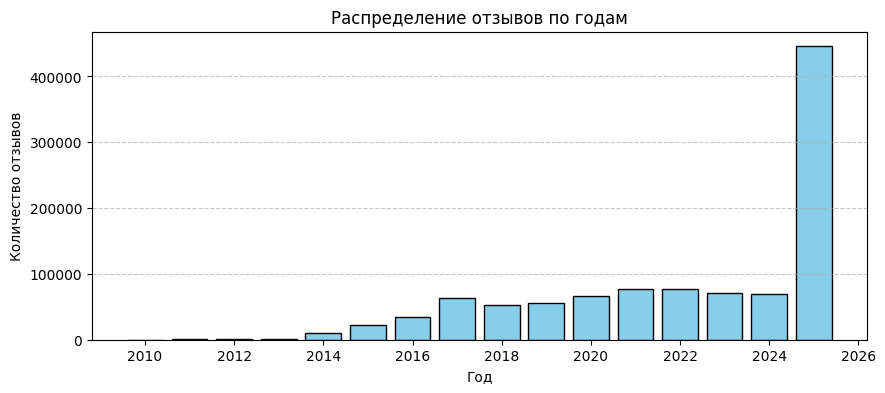

In [13]:
plt.figure(figsize=(10, 4))
plt.bar(reviews_by_year['year'], reviews_by_year['len'], color='skyblue', edgecolor='black')
plt.title("Распределение отзывов по годам")
plt.xlabel("Год")
plt.ylabel("Количество отзывов")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Вывод:** Отзывы охватывают 2010–2025 гг. Пик приходится на 2025 год, так как сбор датасета производился в 2025 году.

### 4. Анализ активности пользователей (User Analysis)

In [14]:
user_stats = reviews_clean.group_by('author_steamid').agg([
    pl.len().alias('user_reviews_count'),
    pl.col('author_playtime_forever').mean().alias('avg_playtime'),
    pl.col('author_num_games_owned').max().alias('games_owned')
])

user_stats.select(['user_reviews_count', 'avg_playtime', 'games_owned']).describe()

statistic,user_reviews_count,avg_playtime,games_owned
str,f64,f64,f64
"""count""",701884.0,647972.0,701884.0
"""null_count""",0.0,53912.0,0.0
"""mean""",1.493324,2444.779951,159.845449
"""std""",5.601683,19570.536591,553.407229
"""min""",1.0,0.0,0.0
"""25%""",1.0,40.0,0.0
"""50%""",1.0,266.0,0.0
"""75%""",1.0,1030.5,135.0
"""max""",2392.0,3.068233e6,39750.0


**Вывод:** В датасете 701k уникальных пользователей. Более 75% пользователей написали ровно 1 отзыв, что показывает высокую разреженность данных.

### 5. Анализ популярности игр (Item Analysis)

In [15]:
item_stats = reviews_clean.group_by('appid').agg([
    pl.len().alias('item_reviews_count')
])

print("Квантили отзывов на игру:")
print(f"50%: {item_stats['item_reviews_count'].quantile(0.5)}")
print(f"90%: {item_stats['item_reviews_count'].quantile(0.9)}")
print(f"99%: {item_stats['item_reviews_count'].quantile(0.99)}")

Квантили отзывов на игру:
50%: 2.0
90%: 22.0
99%: 100.0


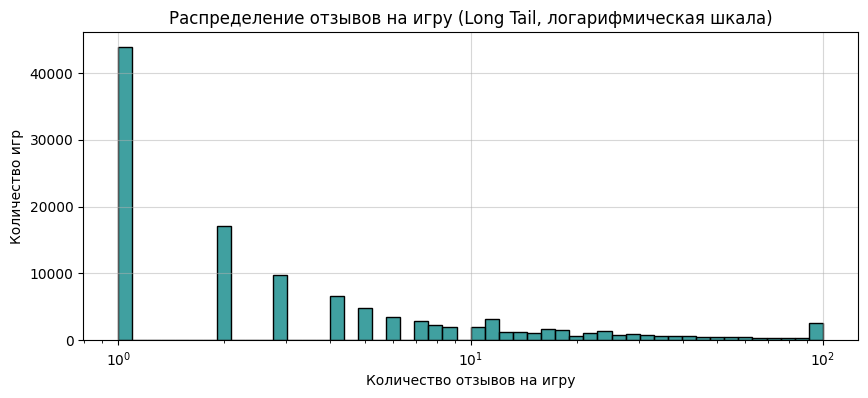

In [19]:
plt.figure(figsize=(10, 4))
sns.histplot(item_stats['item_reviews_count'], bins=50, log_scale=True, color='teal')
plt.title("Распределение отзывов на игру (Long Tail, логарифмическая шкала)")
plt.xlabel("Количество отзывов на игру")
plt.ylabel("Количество игр")
plt.grid(True, alpha=0.5)
plt.show()

**Вывод:** В каталоге 117k игр. 50% игр имеют не более 2 отзывов, а у 99% игр менее 100 отзывов. Наблюдается выраженный эффект длинного хвоста (Long Tail).

### 6. Анализ целевого сигнала времени (`playtime_forever`)

In [25]:
zero_playtime_count = reviews_clean.filter(pl.col('playtime_log1p') == 0).height
print(f"Отзывов с 0 минут игры: {zero_playtime_count:,} ({zero_playtime_count / len(reviews_clean) * 100:.2f}%)")

Отзывов с 0 минут игры: 177,424 (16.93%)


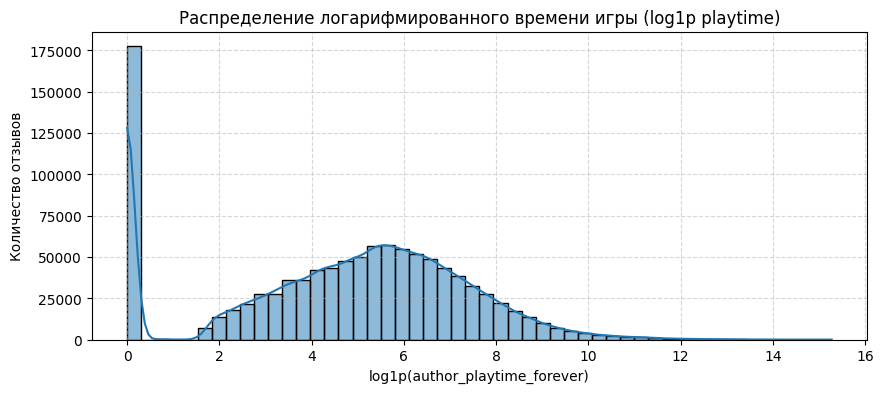

In [28]:
plt.figure(figsize=(10, 4))
sns.histplot(reviews_clean['playtime_log1p'], bins=50, kde=True)
plt.title("Распределение логарифмированного времени игры (log1p playtime)")
plt.xlabel("log1p(author_playtime_forever)")
plt.ylabel("Количество отзывов")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [30]:
reviews_clean.group_by('voted_up').agg([
    pl.len().alias('count'),
    pl.col('author_playtime_forever').median().alias('median_playtime'),
    pl.col('author_playtime_forever').mean().alias('mean_playtime')
])

voted_up,count,median_playtime,mean_playtime
bool,u32,f64,f64
false,250576,56.0,1572.065564
true,797564,239.0,2055.442248


**Вывод:** Игроки с положительным отзывом наиграли в среднем 239 минут против 56 минут у пользователей с негативным отзывом. Время игры прямо отражает увлеченность и подходит как вес взаимодействия для рекомендаций.

### 7. Анализ разреженности и просмотр вариантов K-Core

In [31]:
def print_interactions_stats(df: pl.DataFrame, title: str = "Статистика графа") -> None:
    n_users = df['author_steamid'].n_unique()
    n_items = df['appid'].n_unique()
    n_interactions = len(df)
    sparsity = 100.0 * (1.0 - (n_interactions / (n_users * n_items)))

    user_counts = df.group_by('author_steamid').len()['len']
    game_counts = df.group_by('appid').len()['len']

    print(f"=== {title} ===")
    print(f"Уникальных пользователей: {n_users:,}")
    print(f"Уникальных игр:           {n_items:,}")
    print(f"Взаимодействий (отзывов): {n_interactions:,}")
    print(f"Разреженность (Sparsity): {sparsity:.4f}%\n")

    print("--- Отзывов на пользователя ---")
    print(f"Среднее: {user_counts.mean():.2f}")
    print(f"Квантили (50%, 90%, 99%): {user_counts.quantile(0.5)}, {user_counts.quantile(0.9)}, {user_counts.quantile(0.99)}\n")

    print("--- Отзывов на игру ---")
    print(f"Среднее: {game_counts.mean():.2f}")
    print(f"Квантили (50%, 90%, 99%): {game_counts.quantile(0.5)}, {game_counts.quantile(0.9)}, {game_counts.quantile(0.99)}\n")

In [32]:
print_interactions_stats(reviews_clean, title="Очищенный базовый граф (без K-Core фильтрации)")

=== Очищенный базовый граф (без K-Core фильтрации) ===
Уникальных пользователей: 701,884
Уникальных игр:           117,311
Взаимодействий (отзывов): 1,048,140
Разреженность (Sparsity): 99.9987%

--- Отзывов на пользователя ---
Среднее: 1.49
Квантили (50%, 90%, 99%): 1.0, 2.0, 8.0

--- Отзывов на игру ---
Среднее: 8.93
Квантили (50%, 90%, 99%): 2.0, 22.0, 100.0



In [33]:
def filter_k_core(df: pl.DataFrame, min_user_reviews: int = 3, min_item_reviews: int = 5) -> pl.DataFrame:
    filtered_df = df
    while True:
        prev_len = len(filtered_df)
        active_users = filtered_df.group_by('author_steamid').len().filter(pl.col('len') >= min_user_reviews).select('author_steamid')
        filtered_df = filtered_df.join(active_users, on='author_steamid', how='semi')
        active_games = filtered_df.group_by('appid').len().filter(pl.col('len') >= min_item_reviews).select('appid')
        filtered_df = filtered_df.join(active_games, on='appid', how='semi')
        if len(filtered_df) == prev_len:
            break
    return filtered_df

In [34]:
for u_th, i_th in [(3, 5), (3, 2), (3, 1), (5, 2)]:
    k_core_sample = filter_k_core(reviews_clean, min_user_reviews=u_th, min_item_reviews=i_th)
    print_interactions_stats(k_core_sample, title=f"K-Core вариант: user >= {u_th}, item >= {i_th}")

=== K-Core вариант: user >= 3, item >= 5 ===
Уникальных пользователей: 28,812
Уникальных игр:           16,436
Взаимодействий (отзывов): 188,001
Разреженность (Sparsity): 99.9603%

--- Отзывов на пользователя ---
Среднее: 6.53
Квантили (50%, 90%, 99%): 4.0, 11.0, 47.0

--- Отзывов на игру ---
Среднее: 11.44
Квантили (50%, 90%, 99%): 9.0, 20.0, 47.0

=== K-Core вариант: user >= 3, item >= 2 ===
Уникальных пользователей: 41,449
Уникальных игр:           42,391
Взаимодействий (отзывов): 279,931
Разреженность (Sparsity): 99.9841%

--- Отзывов на пользователя ---
Среднее: 6.75
Квантили (50%, 90%, 99%): 4.0, 11.0, 49.0

--- Отзывов на игру ---
Среднее: 6.60
Квантили (50%, 90%, 99%): 4.0, 14.0, 35.0

=== K-Core вариант: user >= 3, item >= 1 ===
Уникальных пользователей: 47,336
Уникальных игр:           82,010
Взаимодействий (отзывов): 329,458
Разреженность (Sparsity): 99.9915%

--- Отзывов на пользователя ---
Среднее: 6.96
Квантили (50%, 90%, 99%): 4.0, 11.0, 50.0

--- Отзывов на игру ---
Сре

**Вывод:** Без фильтрации разреженность графа составляет 99.998%. Порог (3, 5) сжимает граф до 28.8k пользователей и 16.4k игр, делая его плотным для матричной факторизации. Финальный выбор K-Core сделаем в 3 ноутбуке при обучении моделей.

### 8. Сохранение очищенного датасета

In [36]:
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'reviews_clean.parquet')

reviews_clean.write_parquet(output_path)

print(f"Датасет успешно сохранен в {output_path}")
print(f"Сохранено строк: {reviews_clean.height}, колонок: {reviews_clean.width}")

Датасет успешно сохранен в ../data/processed\reviews_clean.parquet
Сохранено строк: 1048140, колонок: 25
